In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
#display plots inside the notebook

np.set_printoptions(suppress = True) #controls how numpy prints numbers

In [4]:
import warnings
warnings.filterwarnings(action = 'ignore')


In [5]:
import sklearn
sklearn.__version__

'1.6.1'

In [7]:
col_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
             'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal','num']
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data', 
                 header = None, names = col_names)

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [10]:
df.shape

(303, 14)

In [11]:
#preprocessing
df.num.unique()

array([0, 2, 1, 3, 4])

In [12]:
df.num.value_counts()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [13]:
df['num'] = np.where(df.num == 0, 0, 1)

In [14]:
df.num.unique()

array([0, 1])

In [15]:
df['ca'].unique()

array(['0.0', '3.0', '2.0', '1.0', '?'], dtype=object)

In [16]:
df.thal.unique()

array(['6.0', '3.0', '7.0', '?'], dtype=object)

In [19]:
df.replace('?', np.nan, inplace = True) #filling missing values

In [20]:
df['ca'].unique()

array(['0.0', '3.0', '2.0', '1.0', nan], dtype=object)

In [24]:
df.ca = df.ca.astype(float) #converting into float datatype

In [25]:
df.thal = df.thal.astype(float) #converting into float datatype

In [26]:
df['ca'].unique()

array([ 0.,  3.,  2.,  1., nan])

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [29]:
df.num.value_counts() #balanced data

num
0    164
1    139
Name: count, dtype: int64

In [30]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

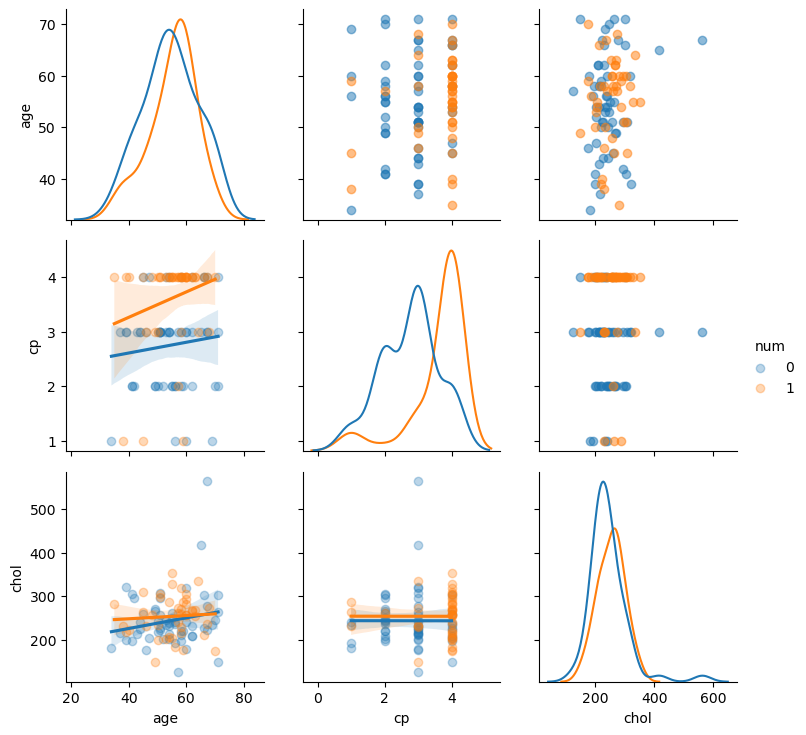

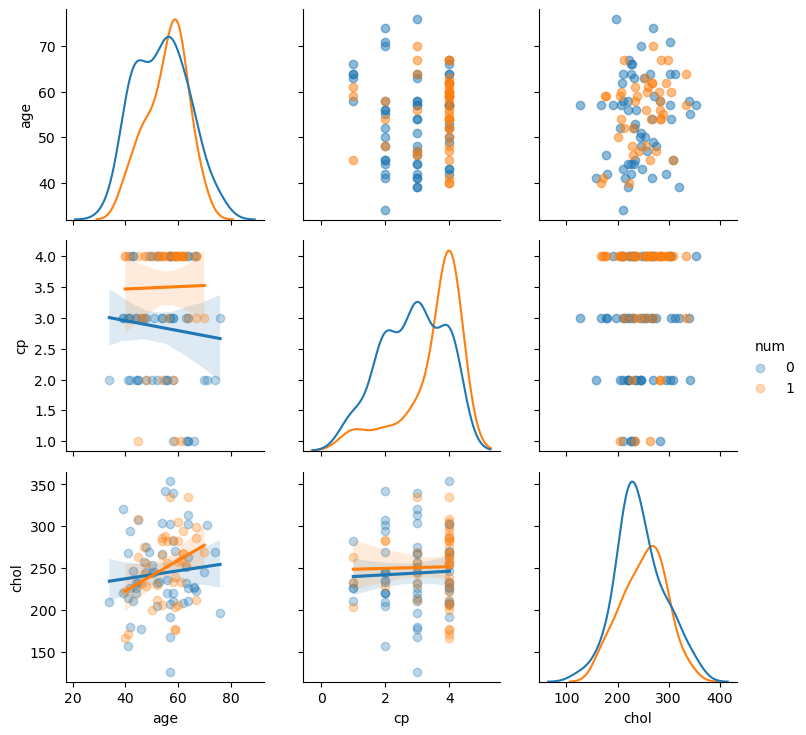

In [35]:
df_small = df[['age', 'cp', 'chol', 'num']] #visualization

g = sns.PairGrid(data = df_small.sample(100), diag_sharey = False, hue = 'num')
g.map_diag(sns.kdeplot)
g.map_upper(plt.scatter, alpha = 0.5)
g.map_lower(sns.regplot, fit_reg = True, scatter_kws = {'alpha':0.3})
g.add_legend()
plt.show()

In [36]:
#train test split
X = df.drop('num', axis = 1)
X 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0


In [37]:
y = df.num
y

0      0
1      1
2      1
3      0
4      0
      ..
298    1
299    1
300    1
301    1
302    0
Name: num, Length: 303, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 20, stratify = y)

In [40]:
pd.DataFrame(X_train).info()

<class 'pandas.core.frame.DataFrame'>
Index: 242 entries, 210 to 21
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       242 non-null    float64
 1   sex       242 non-null    float64
 2   cp        242 non-null    float64
 3   trestbps  242 non-null    float64
 4   chol      242 non-null    float64
 5   fbs       242 non-null    float64
 6   restecg   242 non-null    float64
 7   thalach   242 non-null    float64
 8   exang     242 non-null    float64
 9   oldpeak   242 non-null    float64
 10  slope     242 non-null    float64
 11  ca        240 non-null    float64
 12  thal      240 non-null    float64
dtypes: float64(13)
memory usage: 26.5 KB


In [41]:
from sklearn.impute import SimpleImputer 

In [42]:
imputer = SimpleImputer(strategy = 'most_frequent') #fills the missing values with most frequent values

In [43]:
imputer.fit(X_train)

SimpleImputer(strategy='most_frequent')

In [44]:
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

In [45]:
X.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [46]:
X_train = pd.DataFrame(X_train, columns = X.columns)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       242 non-null    float64
 1   sex       242 non-null    float64
 2   cp        242 non-null    float64
 3   trestbps  242 non-null    float64
 4   chol      242 non-null    float64
 5   fbs       242 non-null    float64
 6   restecg   242 non-null    float64
 7   thalach   242 non-null    float64
 8   exang     242 non-null    float64
 9   oldpeak   242 non-null    float64
 10  slope     242 non-null    float64
 11  ca        242 non-null    float64
 12  thal      242 non-null    float64
dtypes: float64(13)
memory usage: 24.7 KB


In [47]:
X_test = pd.DataFrame(X_test, columns = X.columns)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       61 non-null     float64
 1   sex       61 non-null     float64
 2   cp        61 non-null     float64
 3   trestbps  61 non-null     float64
 4   chol      61 non-null     float64
 5   fbs       61 non-null     float64
 6   restecg   61 non-null     float64
 7   thalach   61 non-null     float64
 8   exang     61 non-null     float64
 9   oldpeak   61 non-null     float64
 10  slope     61 non-null     float64
 11  ca        61 non-null     float64
 12  thal      61 non-null     float64
dtypes: float64(13)
memory usage: 6.3 KB


In [48]:
#one hot encoding
#dummy encoding using pandas
X_train_dummy = X_train.copy()
X_test_dummy = X_test.copy()

X_train_dummy['train_test'] = 'train'
X_test_dummy['train_test'] = 'test'

In [49]:
X_combi = pd.concat([X_train_dummy, X_test_dummy], axis = 0)

In [50]:
X_combi = pd.get_dummies(data = X_combi, columns = ['cp', 'restecg', 'slope', 'thal'])

In [51]:
X_combi.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,train_test,...,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0
0,37.0,0.0,120.0,215.0,0.0,170.0,0.0,0.0,0.0,train,...,False,True,False,False,True,False,False,True,False,False
1,57.0,0.0,140.0,241.0,0.0,123.0,1.0,0.2,0.0,train,...,True,True,False,False,False,True,False,False,False,True
2,69.0,1.0,160.0,234.0,1.0,131.0,0.0,0.1,1.0,train,...,False,False,False,True,False,True,False,True,False,False
3,43.0,1.0,120.0,177.0,0.0,120.0,1.0,2.5,0.0,train,...,True,False,False,True,False,True,False,False,False,True
4,58.0,0.0,130.0,197.0,0.0,131.0,0.0,0.6,0.0,train,...,True,True,False,False,False,True,False,True,False,False


In [52]:
X_train_dummy = X_combi.loc[X_combi['train_test'] == 'train', :]
X_test_dummy = X_combi.loc[X_combi['train_test'] == 'test', :]

X_train_dummy = X_train_dummy.drop('train_test', axis=1)
X_test_dummy = X_test_dummy.drop('train_test', axis=1)

In [53]:
X_train_dummy.columns

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'ca', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0',
       'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0',
       'thal_3.0', 'thal_6.0', 'thal_7.0'],
      dtype='object')

In [54]:
#1hotencoding using variable names in sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer, ColumnTransformer

In [55]:
ohe = OneHotEncoder()

In [56]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [57]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [58]:
ct = ColumnTransformer(
    transformers = [('ohe', ohe, ['cp', 'restecg', 'slope', 'thal'])], 
    remainder = "passthrough")

In [59]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,37.0,0.0,3.0,120.0,215.0,0.0,0.0,170.0,0.0,0.0,1.0,0.0,3.0
1,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0
2,69.0,1.0,1.0,160.0,234.0,1.0,2.0,131.0,0.0,0.1,2.0,1.0,3.0
3,43.0,1.0,4.0,120.0,177.0,0.0,2.0,120.0,1.0,2.5,2.0,0.0,7.0
4,58.0,0.0,4.0,130.0,197.0,0.0,0.0,131.0,0.0,0.6,2.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,58.0,0.0,4.0,170.0,225.0,1.0,2.0,146.0,1.0,2.8,2.0,2.0,6.0
238,56.0,1.0,1.0,120.0,193.0,0.0,2.0,162.0,0.0,1.9,2.0,0.0,7.0
239,44.0,1.0,4.0,112.0,290.0,0.0,2.0,153.0,0.0,0.0,1.0,1.0,3.0
240,59.0,1.0,2.0,140.0,221.0,0.0,0.0,164.0,1.0,0.0,1.0,0.0,3.0


In [60]:
ct.fit(X_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe', OneHotEncoder(),
                                 ['cp', 'restecg', 'slope', 'thal'])])

In [61]:
ct.transform(X_train).shape

(242, 22)

In [62]:
df['cp'].unique()

array([1., 4., 3., 2.])

In [63]:
ct.transformers_[0][1].categories_

[array([1., 2., 3., 4.]),
 array([0., 1., 2.]),
 array([1., 2., 3.]),
 array([3., 6., 7.])]

In [64]:
X_train2 = ct.transform(X_train)
X_test2 = ct.transform(X_test)

In [65]:
X_train2[0]

array([  0.,   0.,   1.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   1.,
         0.,   0.,  37.,   0., 120., 215.,   0., 170.,   0.,   0.,   0.])

In [66]:
ct.get_feature_names_out()

array(['ohe__cp_1.0', 'ohe__cp_2.0', 'ohe__cp_3.0', 'ohe__cp_4.0',
       'ohe__restecg_0.0', 'ohe__restecg_1.0', 'ohe__restecg_2.0',
       'ohe__slope_1.0', 'ohe__slope_2.0', 'ohe__slope_3.0',
       'ohe__thal_3.0', 'ohe__thal_6.0', 'ohe__thal_7.0',
       'remainder__age', 'remainder__sex', 'remainder__trestbps',
       'remainder__chol', 'remainder__fbs', 'remainder__thalach',
       'remainder__exang', 'remainder__oldpeak', 'remainder__ca'],
      dtype=object)

In [67]:
X_train2.shape 

(242, 22)

In [69]:
X_test2.shape
#both train and test set should have same no of columns

(61, 22)

In [70]:
#onehotencoding using mask in sklearn
mask = X.columns.isin(['cp', 'restecg', 'slope', 'thal'])
mask

array([False, False,  True, False, False, False,  True, False, False,
       False,  True, False,  True])

In [72]:
ct2 = make_column_transformer(
    (OneHotEncoder(sparse_output = False), mask),
    remainder = 'passthrough'
)

In [73]:
ct2.fit(X_train)

X_train3 = ct2.transform(X_train)
X_test3 = ct2.transform(X_test)

In [74]:
np.not_equal(X_train2, X_train3).sum()

np.int64(0)

In [75]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [77]:
clf = LogisticRegression(max_iter = 5000)

In [78]:
clf.fit(X_train2, y_train)

LogisticRegression(max_iter=5000)

In [79]:
clf.classes_

array([0, 1])

In [81]:
print('Iterations:', clf.n_iter_)

Iterations: [1357]


In [82]:
pred = clf.predict(X_test3)
pred

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0])

In [83]:
metrics.accuracy_score(y_test, pred)

0.9016393442622951

In [84]:
(y_test == pred).mean()

np.float64(0.9016393442622951)

In [85]:
metrics.zero_one_loss(y_test, pred) + metrics.accuracy_score(y_test, pred)

1.0

In [86]:
pd.DataFrame(metrics.confusion_matrix(y_test, pred))

,0,1
0,32,1
1,5,23


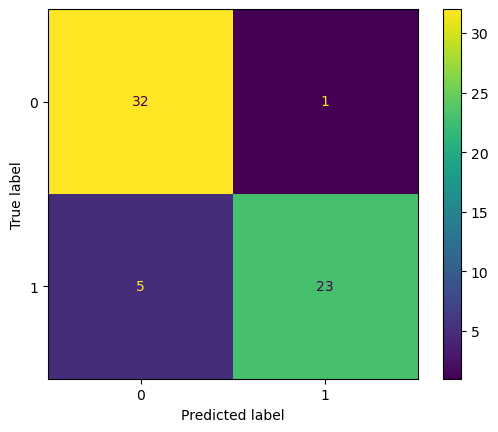

In [89]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred);
plt.show()

In [92]:
metrics.recall_score(y_test, pred, pos_label = 1)

0.8214285714285714

In [93]:
print(metrics.classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91        33
           1       0.96      0.82      0.88        28

    accuracy                           0.90        61
   macro avg       0.91      0.90      0.90        61
weighted avg       0.91      0.90      0.90        61



In [94]:
clf = LogisticRegression(C = 1) #lr model

In [95]:
C_vals = [0.0001, 0.001, 0.01, 0.03, 0.1, 0.3, 1, 2, 5, 10, 15, 20, 50, 100, 1000, 10000, 100000]
C_vals

[0.0001,
 0.001,
 0.01,
 0.03,
 0.1,
 0.3,
 1,
 2,
 5,
 10,
 15,
 20,
 50,
 100,
 1000,
 10000,
 100000]

In [96]:
scores = []

for C in C_vals:
    clf = LogisticRegression(C = C, max_iter = 2000)
    clf.fit(X_train3, y_train)
    
    print('Iterations:', clf.n_iter_)
    
    pred=clf.predict(X_test3)
    scores.append(metrics.zero_one_loss(y_test, pred))

Iterations: [70]
Iterations: [135]
Iterations: [173]
Iterations: [326]
Iterations: [448]
Iterations: [801]
Iterations: [1357]
Iterations: [1477]
Iterations: [1903]
Iterations: [1775]
Iterations: [1853]
Iterations: [1866]
Iterations: [2000]
Iterations: [1108]
Iterations: [943]
Iterations: [1113]
Iterations: [783]


In [97]:
scores

[0.4098360655737705,
 0.42622950819672134,
 0.3114754098360656,
 0.180327868852459,
 0.08196721311475408,
 0.11475409836065575,
 0.09836065573770492,
 0.1311475409836066,
 0.1311475409836066,
 0.1311475409836066,
 0.1311475409836066,
 0.1311475409836066,
 0.1311475409836066,
 0.1311475409836066,
 0.1311475409836066,
 0.1311475409836066,
 0.1311475409836066]

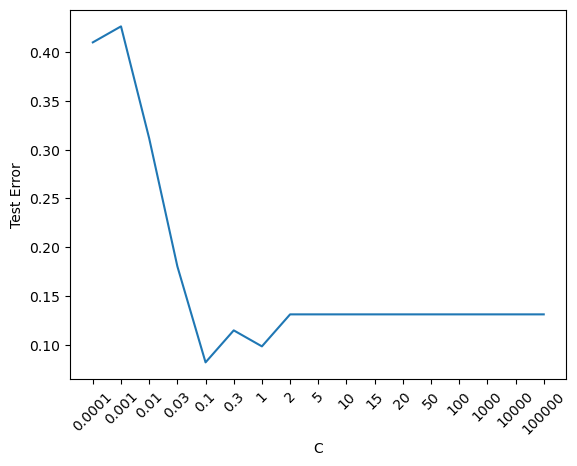

In [98]:
plt.plot(scores)
plt.xticks(np.arange(len(C_vals)), C_vals, rotation = 45)
plt.xlabel('C')
plt.ylabel('Test Error')

plt.show()

In [99]:
# bias and variance 
X_train_val, X_val, y_train_val, y_val = train_test_split(X_train2, y_train, test_size = 0.20, random_state = 20)

In [100]:
#validation curve
scores_tr = []
scores_val = []

for C in C_vals:
    clf = LogisticRegression(C = C, max_iter = 2000)
    clf.fit(X_train_val, y_train_val)
    
    print('Iterations:',clf.n_iter_)

    pred = clf.predict(X_train_val)
    scores_tr.append(metrics.accuracy_score(y_train_val, pred))
    
    pred = clf.predict(X_val)
    scores_val.append(metrics.accuracy_score(y_val, pred))

Iterations: [47]
Iterations: [68]
Iterations: [230]
Iterations: [307]
Iterations: [450]
Iterations: [782]
Iterations: [1188]
Iterations: [1512]
Iterations: [1670]
Iterations: [1844]
Iterations: [1760]
Iterations: [2000]
Iterations: [2000]
Iterations: [870]
Iterations: [2000]
Iterations: [2000]
Iterations: [2000]


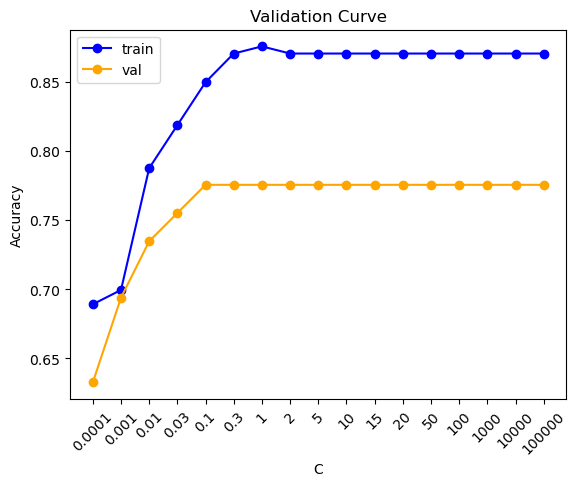

In [104]:
#visualization
f, ax = plt.subplots(dpi = 100)

plt.plot(scores_tr, marker = 'o', color = 'blue', label = 'train')
plt.plot(scores_val, color = 'orange', marker = 'o', label = 'val')
plt.title('Validation Curve')
plt.xticks(ticks = np.arange(len(C_vals)), labels = C_vals, rotation = 45)
plt.xlabel('C')
plt.ylabel('Accuracy')

plt.legend()
plt.show()


In [105]:
#learning curve
y_train_val

200    0
34     0
225    0
69     1
14     0
      ..
235    1
136    1
63     0
40     1
9      1
Name: num, Length: 193, dtype: int64

In [106]:
X_train_val.shape[0]

193

In [107]:
accuracy_train = []
accuracy_val = []

clf = LogisticRegression(max_iter = 1000, solver = 'lbfgs', penalty = 'l2', C = 1, verbose = 0)

num_points = list(range(5, X_train_val.shape[0], 10))

for n in num_points:
    clf.fit(X_train_val[0:n, :], y_train_val[0:n])
    pred_trn = clf.predict(X_train_val[0:n, :])
    accuracy_train.append(metrics.accuracy_score(y_true = y_train_val[0:n], y_pred = pred_trn))
    pred_val = clf.predict(X_val)
    accuracy_val.append(metrics.accuracy_score(y_true = y_val, y_pred = pred_val))

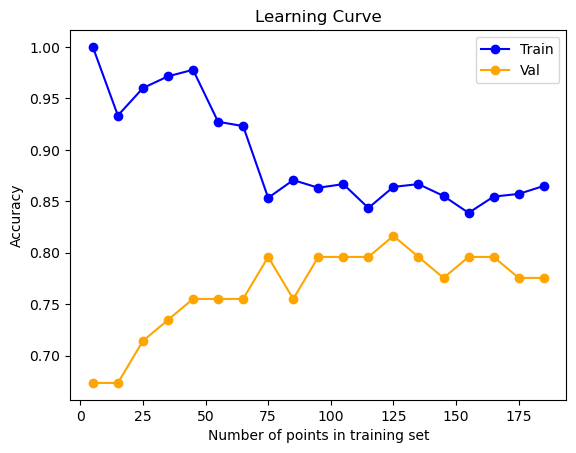

In [110]:
f, ax = plt.subplots(dpi = 100)

ax.plot(num_points, accuracy_train, marker = 'o', color = 'blue', label = 'Train')
ax.plot(num_points, accuracy_val, marker = 'o', color = 'orange', label = 'Val')

ax.set_xlabel('Number of points in training set')
ax.set_ylabel('Accuracy')
ax.set_title("Learning Curve")

ax.legend();
plt.show();

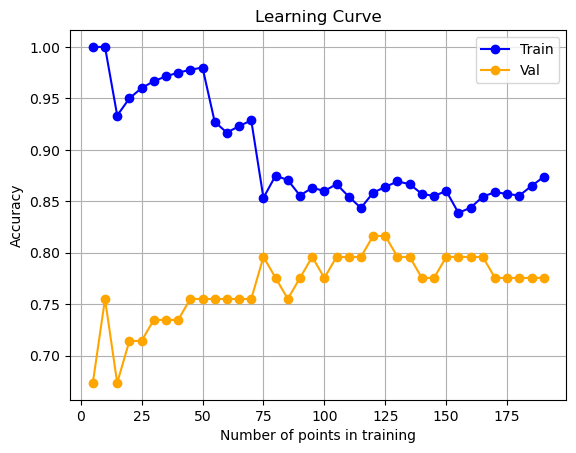

In [114]:
#decreasing  interval length among training curves gives the smoother curves
accuracy_train = []
accuracy_val = []

clf = LogisticRegression(max_iter = 1000, solver = 'lbfgs', penalty = 'l2', C = 1, verbose = 0)

num_points = list(range(5, X_train_val.shape[0], 5))

for n in num_points:
    clf.fit(X_train_val[0:n, :], y_train_val[0:n])
    pred_trn = clf.predict(X_train_val[0:n, :])
    accuracy_train.append(metrics.accuracy_score(y_true = y_train_val[0:n], y_pred = pred_trn))
    pred_val = clf.predict(X_val)
    accuracy_val.append(metrics.accuracy_score(y_true = y_val, y_pred = pred_val))

#visualization
f, ax = plt.subplots(dpi = 100)
ax.plot(num_points, accuracy_train, marker = 'o', color = 'blue', label = 'Train')
ax.plot(num_points, accuracy_val, marker = 'o', color = 'orange', label = 'Val')

ax.set_xlabel('Number of points in training')
ax.set_ylabel('Accuracy')
ax.set_title("Learning Curve")

ax.legend();
ax.grid()
plt.show();